# Explore anomaly scores

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from anomaly.constants import GALAXY_LINES
from anomaly.utils import specobjid_to_idx
from anomaly.utils import VelocityFilter
from autoencoders.ae import AutoEncoder

from sdss.metadata import MetaData

meta = MetaData()

# Constants

In [103]:
mse_cols = ['mse', 'mse_filter_250', 'mse_97', 'mse_filter_250_97']
mse_rel_cols = ['mse_rel', 'mse_filter_250_rel', 'mse_97_rel', 'mse_filter_250_97_rel']

# Custom functions

## Scores arr to df

In [4]:
def scores_arr_to_df(score_paths, bin_idx_to_specobjid):

    score_names = [score.split("/")[-1][:-4] for score in score_paths]
    objids_bin = bin_idx_to_specobjid[:, 1]

    scores_dict = {}

    for score_name, score_path in zip(score_names, score_paths):

        scores_dict[score_name] = np.load(score_path)[:, 0]

    scores_df = pd.DataFrame(data=scores_dict, index=objids_bin)
    scores_df.index.name = 'specobjid'
    scores_df.sort_values(by='mse', ascending=False, inplace=True)

    return scores_df[mse_cols + mse_rel_cols]


In [ ]:
## Residuals

In [5]:
def residual_mse(spec, spec_rec):

    flux_diff = np.abs(spec - spec_rec)
    
    return flux_diff

## score Vs z \& S/N

In [128]:
def plot_hist_score_z_snr(
    df,
    score_family,
    x_col, x_label,
    gridsize=100
):
    """
    Generates a 2x2 grid of hexbin plots for a given list of 4
    scores against a metadata column.
    """
    fig, axs = plt.subplots(
        2, 2,
        sharex=True,
        figsize=(20, 9)
    )
    
    axs = axs.flatten()

    for i, score in enumerate(score_family):
        # Create the hexbin plot
        hb = axs[i].hexbin(
            df[x_col], 
            df[score], 
            gridsize=gridsize, 
            cmap='viridis',
            mincnt=1, 
            bins='log'
        )
        
        # Formatting
        axs[i].minorticks_on()
        axs[i].text(
            0.95, 0.95,
            score,
            horizontalalignment="right", verticalalignment="center",
            transform=axs[i].transAxes,
            fontsize=12
        )

        if i == 2 or i == 3:
            axs[i].set_xlabel(x_label, fontsize=12)
        
        # Add colorbar
        cb = fig.colorbar(hb, ax=axs[i])
        if i == 1 or i == 3:
            cb.set_label('Log10(Count)')

    return fig, axs

# Directories

In [6]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
bin_ids = [f"bin_{i:02d}" for i in range(4)]
#
ch_4_dir = f"{thesis_dir}/chapters/04_figures"

# Data

In [7]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_03 = np.load(
    f"{spectra_dir}/bin_03/bin_03_index_specobjid.npy"
)

# Model

In [8]:
ae_03 = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/bin_03/winner",
)

# Build csv with scores for each bin

```python
bin_id = 'bin_03'

score_paths = glob.glob(f"{scores_dir}/{bin_id}/*.npy")

bin_idx_to_specobjid = np.load(
    f"{spectra_dir}/"
    f"{bin_id}/{bin_id}_index_specobjid.npy"
)

scores_df = scores_arr_to_df(score_paths, bin_idx_to_specobjid)
scores_df.to_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index=True
)
```

```python
for bin_id in bin_ids:

    score_paths = glob.glob(f"{scores_dir}/{bin_id}/*.npy")

    bin_idx_to_specobjid = np.load(
        f"{spectra_dir}/"
        f"{bin_id}/{bin_id}_index_specobjid.npy"
    )

    scores_df = scores_arr_to_df(score_paths, bin_idx_to_specobjid)
    scores_df.to_csv(
        f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
        index=True
    )
```

## Bind 03

In [9]:
bin_id = 'bin_03'
score_03_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)

In [43]:
score_03_df.columns.to_list()

['mse',
 'mse_97',
 'mse_filter_250',
 'mse_filter_250_97',
 'mse_rel',
 'mse_97_rel',
 'mse_filter_250_rel',
 'mse_filter_250_97_rel']

In [10]:
score_03_df.loc[1945689783355336704]

mse                      17.067748
mse_97                   15.249345
mse_filter_250           16.994252
mse_filter_250_97        15.183400
mse_rel                  16.630739
mse_97_rel               15.008672
mse_filter_250_rel       16.562386
mse_filter_250_97_rel    14.942477
Name: 1945689783355336704, dtype: float64

In [11]:
n_spec = score_03_df.shape[0]
n_tops = [int(n_spec*p) for p in [0.001, 0.005, 0.01, 0.05]]
n_tops_perc = [f'{n/n_spec*100:.2f}%' for n in n_tops]

In [12]:
n_tops, n_tops_perc

([181, 909, 1818, 9092], ['0.10%', '0.50%', '1.00%', '5.00%'])

# Illustration of scores

In [26]:
bad_specobjid = 531492683672217600
idx_bad = specobjid_to_idx(bad_specobjid, idx_id_03)
spec_bad = spectra[idx_bad]
spec_bad_rec = ae_03.reconstruct(spec_bad).reshape(-1)
residual_bad = residual_mse(spec_bad, spec_bad_rec)
threshold_bad_3 = np.nanpercentile(residual_bad, 97)
print(f"Ignore 3% threshold: {threshold_bad_3}")
# -------------------------------------------------
broad_specobjid = 1924292192684238848
idx_broad = specobjid_to_idx(broad_specobjid, idx_id_03)
spec_broad = spectra[idx_broad]
spec_broad_rec = ae_03.reconstruct(spec_broad).reshape(-1)
residual_broad = residual_mse(spec_broad, spec_bad_rec)
threshold_broad_3 = np.nanpercentile(residual_broad, 97)
print(f"Ignore 3% threshold: {threshold_broad_3}")
# -------------------------------------------------
score_03_df.loc[[bad_specobjid, broad_specobjid]]

Ignore 3% threshold: 0.31668755531311027
Ignore 3% threshold: 0.9138420844078061


,mse,mse_97,mse_filter_250,mse_filter_250_97,mse_rel,mse_97_rel,mse_filter_250_rel,mse_filter_250_97_rel
specobjid,,,,,,,,
531492683672217600,29.718512,26.180044,29.422013,26.051243,28.066405,26.032973,27.933711,25.945725
1924292192684238848,44.160318,15.315991,41.574367,15.108849,21.568775,13.925405,20.861547,13.805299


In [27]:
emission_lines = list(GALAXY_LINES.keys())

velocity_fil_fn = VelocityFilter(
    wave=wave, velocity_filter=250,
    lines=emission_lines
)

vel_mask = velocity_fil_fn.get_velocity_filter_mask()

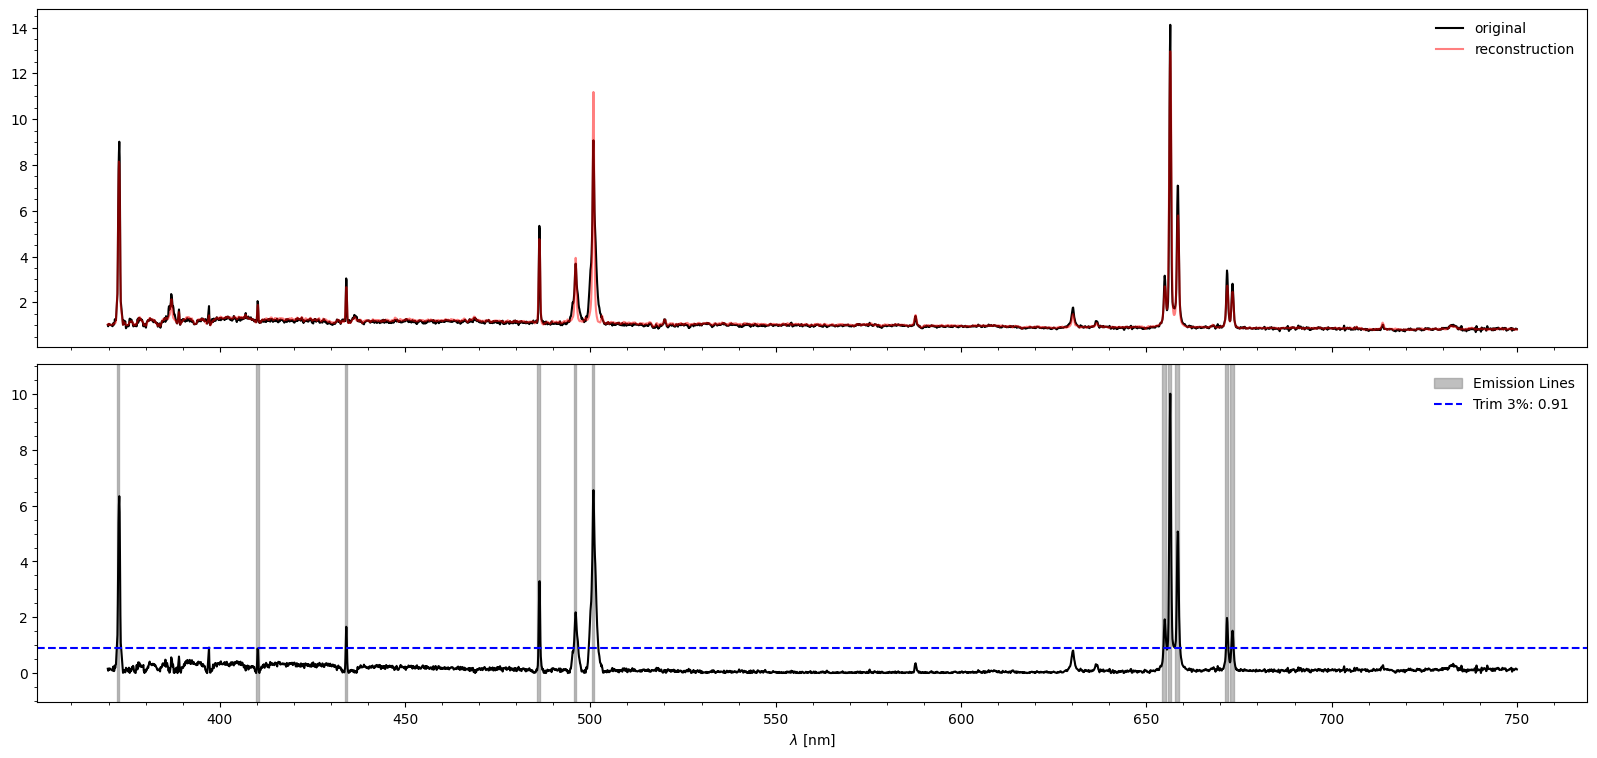

In [ ]:
fig, axs = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(20, 9)
)
# ----------------------------------------------------
axs[0].plot(wave_nm, spec_broad, color='black', alpha=1, label='original')
axs[0].plot(wave_nm, spec_broad_rec, color='red', alpha=0.5, label='reconstruction')
# ----------------------------------------------------
axs[1].plot(wave_nm, residual_broad, color='black')
# ----------------------------------------------------
# shaded regions
    
axs[1].fill_between(
    wave_nm, 
    0, 1,              # Fill from bottom (0) to top (1) of the axis
    where=~vel_mask,    # Only where your mask is True
    color='gray',      # Color of the shade
    alpha=0.5,         # Transparency
    transform=axs[1].get_xaxis_transform(), # Key: maps y to axis fractions
    label='Emission Lines'
)
# ----------------------------------------------------
# Lower Panel Right: Broad Residuals
axs[1].axhline(
    y=threshold_broad_3, 
    color='blue', 
    linestyle='--', 
    linewidth=1.5,
    label=f'Trim 3%: {threshold_broad_3:.2f}'
)

# ----------------------------------------------------
# leggends
axs[0].legend(loc='upper right', frameon=False, fontsize=10)
axs[1].legend(loc='upper right', frameon=False, fontsize=10)
# ---------------------------------------------------- 
for ax in axs.flatten(): ax.minorticks_on()
# ---------------------------------------------------- 

axs[1].set_xlabel(r"$\lambda$ [nm]")
# ---------------------------------------------------- 
plt.subplots_adjust(hspace=0.05, wspace=0.05)
# ---------------------------------------------------- 
fig.savefig(
    f"{ch_4_dir}/score_methodology_example.pdf",
    bbox_inches='tight'
)

# Histograms Scores

## Data prep

In [123]:
merged_df = score_03_df.join(final_meta_df[['z', 'snMedian']], how='inner').copy()
score_cols = mse_cols + mse_rel_cols
merged_df[score_cols] = merged_df[score_cols] / merged_df[score_cols].max()

In [125]:
bad_specobjid = 531492683672217600
broad_specobjid = 1924292192684238848
merged_df.loc[[bad_specobjid, broad_specobjid], score_cols]

,mse,mse_filter_250,mse_97,mse_filter_250_97,mse_rel,mse_filter_250_rel,mse_97_rel,mse_filter_250_97_rel
specobjid,,,,,,,,
531492683672217600,0.082372,0.081551,0.493177,0.490790,0.096069,0.097361,0.354965,0.353844
1924292192684238848,0.122401,0.115234,0.288521,0.284642,0.073828,0.072712,0.189876,0.188275


## Score descriptive stats

In [126]:
merged_df[score_cols].describe()

,mse,mse_filter_250,mse_97,mse_filter_250_97,mse_rel,mse_filter_250_rel,mse_97_rel,mse_filter_250_97_rel
count,181850.000000,181850.000000,181850.000000,181850.000000,181850.000000,181850.000000,181850.000000,181850.000000
mean,0.026591,0.025821,0.114747,0.114154,0.033209,0.032803,0.095503,0.094875
std,0.031610,0.030037,0.100608,0.100052,0.035689,0.033989,0.083861,0.083221
min,0.002429,0.002369,0.013517,0.013464,0.003470,0.003359,0.010940,0.010870
25%,0.008703,0.008613,0.048428,0.048225,0.012691,0.012716,0.040187,0.039970
50%,0.014591,0.014402,0.074368,0.074006,0.020435,0.020479,0.062560,0.062184
75%,0.032453,0.031887,0.142819,0.141945,0.040491,0.040496,0.120287,0.119434
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Top 1% score thresholds

In [127]:
top_1_thresholds = merged_df[score_cols].quantile(0.99)
print("Score thresholds for the Top 1% of anomalies:")
print("-" * 40)
print(top_1_thresholds)

Score thresholds for the Top 1% of anomalies:
----------------------------------------
mse                      0.145514
mse_filter_250           0.136169
mse_97                   0.479384
mse_filter_250_97        0.477039
mse_rel                  0.171528
mse_filter_250_rel       0.160378
mse_97_rel               0.406240
mse_filter_250_97_rel    0.402890
Name: 0.99, dtype: float64


## MSE family dist

## Chi sq family dist

# Scores Vs metadata histograms

## Redshift

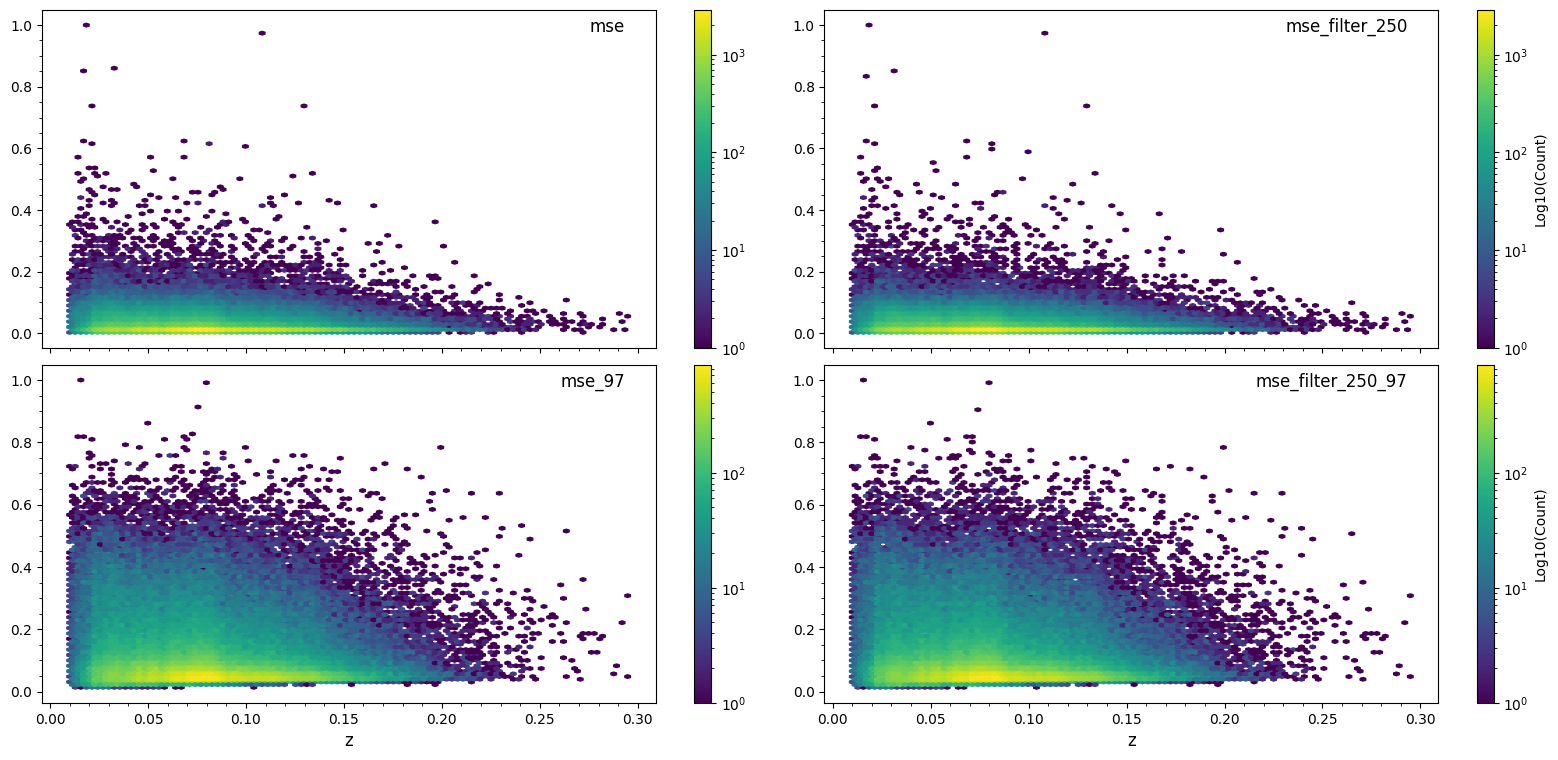

In [129]:
fig, axs = plot_hist_score_z_snr(merged_df, mse_family, 'z', 'z')
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.02
)

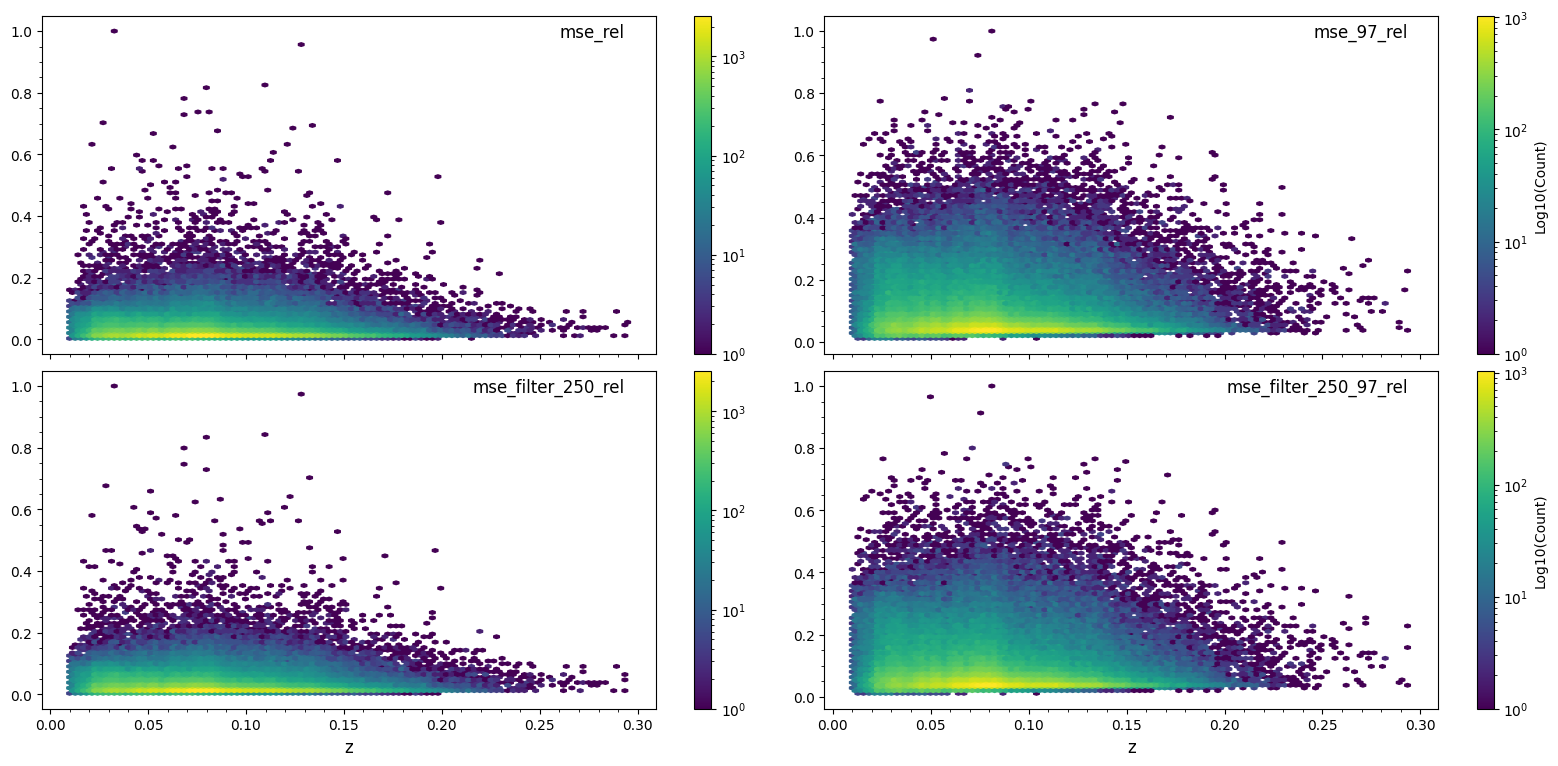

In [130]:
fig, axs = plot_hist_score_z_snr(merged_df, chi_sq_family, 'z', 'z')
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.02
)

## S/N

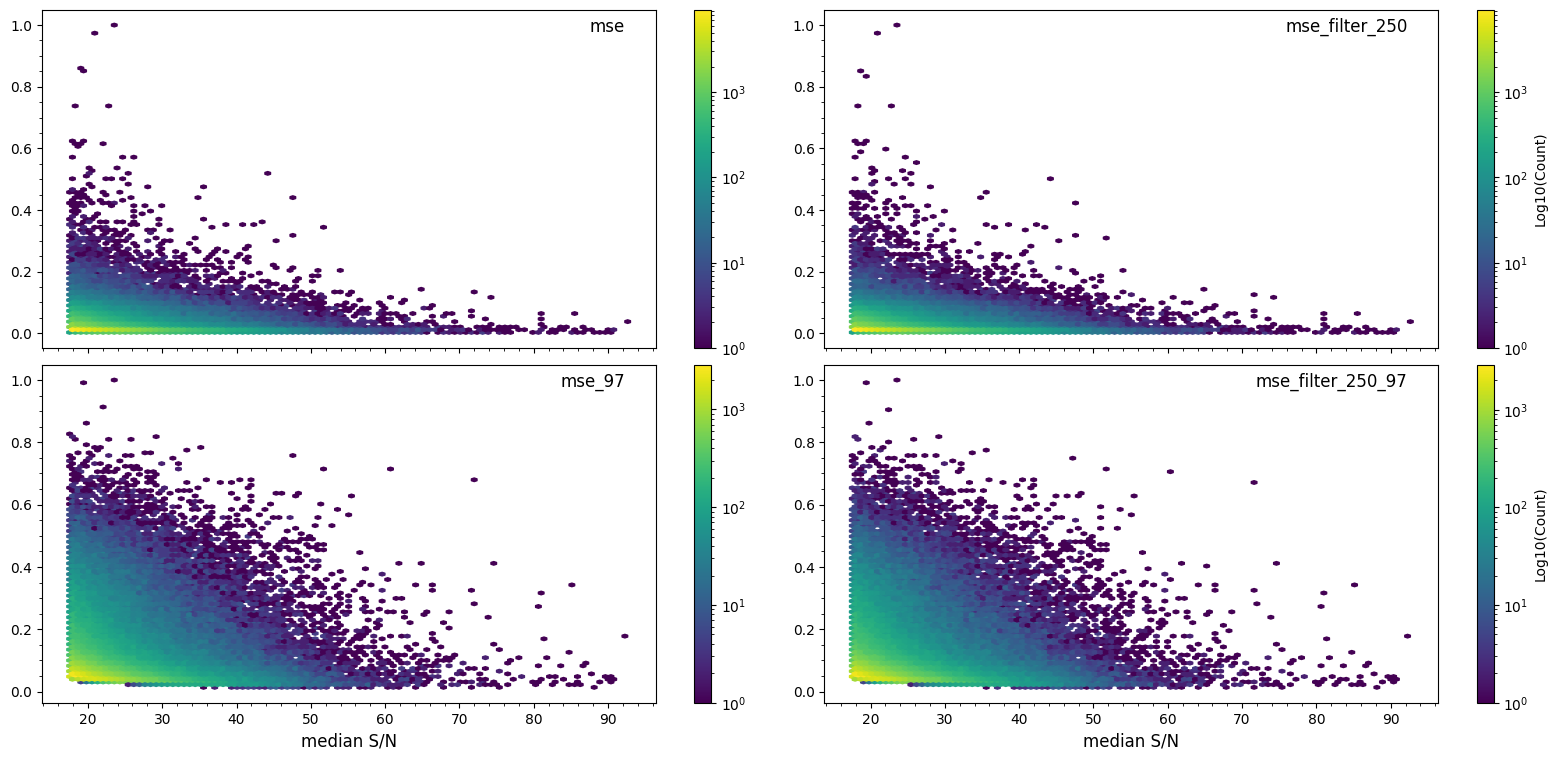

In [131]:
fig, axs = plot_hist_score_z_snr(merged_df, mse_family, 'snMedian', 'median S/N')
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.02
)

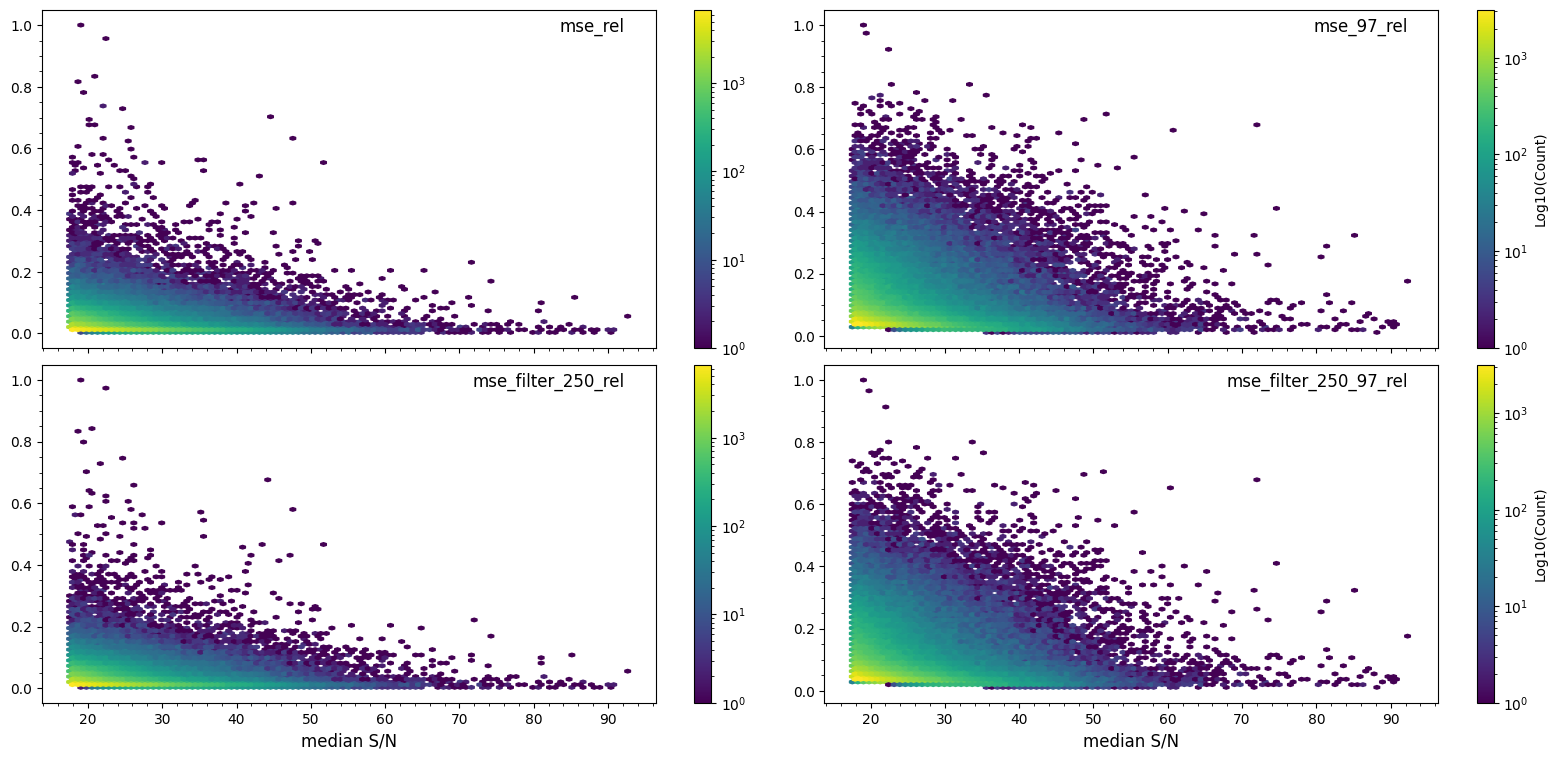

In [132]:
fig, axs = plot_hist_score_z_snr(merged_df, chi_sq_family, 'snMedian', 'median S/N')
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.02
)

# Median Specs

## MSE

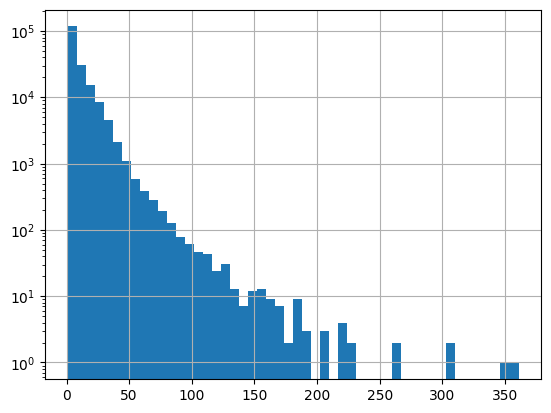

In [24]:
score_03_df.mse.hist(bins=50)
plt.yscale('log')